In [ ]:
# MultiPhase AM Model Training with Animated Forecasting
%reload_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from model.AM import MultiPhaseAMModel
from data.AM_dataset import RowDataset, MultiPhaseDataset, row_collate_fn
from torch.utils.data import DataLoader

# Parameters
input_dim = 1
num_inducing_points = 10
num_latents = 2
num_outputs = 2
num_epochs = 300
plot_every = 10
device = "cuda:0"

# Load dataset
data_path = '/mnt/data/yiwang/code/RandomMaterial/clustered_grain/massive_05_testify_bilevel_sampling_2phases_with_clustered_grains'
material_dataset = MultiPhaseDataset(data_path, [512,512], n_phases=2)
row_dataset = RowDataset(material_dataset, rows_per_image=400)
row_loader = DataLoader(row_dataset, batch_size=400, shuffle=False, collate_fn=row_collate_fn)

loaders = iter(row_loader)
train_batch = next(loaders)
test_batch = next(loaders)

Y_train, labels_train = train_batch
X_train = torch.linspace(0, 1, Y_train.shape[1]).reshape(1, -1).repeat(Y_train.shape[0], 1)
Y_train.squeeze_()

Y_test, labels_test = test_batch
Y_test.squeeze_()
X_test = torch.linspace(0, 1, Y_test.shape[1]).reshape(1, -1).repeat(Y_test.shape[0], 1)

# Utility

def unpack_data_1d(X, Y, labels):
    x_list_by_class, y_list_by_class = [], []
    for label in [0, 1]:
        x_list = [x for x, l in zip(X, labels) if l == label]
        y_list = [y for y, l in zip(Y, labels) if l == label]
        x_list_by_class.append(torch.tensor(np.stack(x_list), dtype=torch.float32).unsqueeze(-1).to(device))
        y_list_by_class.append(torch.tensor(np.stack(y_list), dtype=torch.float32).unsqueeze(-1).to(device))
    return x_list_by_class, y_list_by_class

# Model & Optimizer
model = MultiPhaseAMModel(input_dim, num_inducing_points, num_latents, num_outputs, sigma_y=0.1).to(device)
x_list_by_class, y_list_by_class = unpack_data_1d(X_train, Y_train, labels_train)

kernel_vars = [p for name, p in model.named_parameters() if 'kernel' in name]
encoding_vars = [p for name, p in model.named_parameters() if 'kernel' not in name]
optimizer = torch.optim.Adam([
    {'params': kernel_vars, 'lr': 1e-3},
    {'params': encoding_vars, 'lr': 5e-3}
])

# Forecast plot

def plot_forecast(X, Y, label=0):
    test_time = np.linspace(0, 1.0, 50, endpoint=False)
    with torch.no_grad():
        means, covars, S_ms = model.forecast(torch.tensor(test_time, dtype=torch.float32).to(device).unsqueeze(0))
        Sm = S_ms[label].detach().cpu().numpy()
        prior_mean = model.freq_model.gaussian_processes[label].variational_mean.squeeze().detach().cpu().numpy()
        mean = means[label].squeeze().detach().cpu().numpy()
        covar = covars[label].squeeze().detach().cpu().numpy()
    std = np.sqrt(np.diag(covar))

    fig, ax = plt.subplots()
    X = X[labels_train == label]
    Y = Y[labels_train == label]
    Y, _ = model.transmute(Y)
    Y = Y.detach().cpu().numpy()
    for i in range(min(10,X.shape[0])):
        ax.plot(test_time, Y[i], color='blue', lw=0.5, alpha=0.5)
    ax.plot(test_time, mean, color='red', lw=2, label='Mean prediction')
    ax.fill_between(test_time, mean + 2*std, mean - 2*std, color='red', alpha=0.2)
    ax.scatter(Sm, prior_mean, color='green', s=45, label='Most informative timestamps')
    ax.set_title(f'Forecast class {label}')

    ax.legend()
    return fig

# Classification

def classify(model, X_test, Y_test, L_test):
    model.eval()
    with torch.no_grad():
        #X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        #Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)
        X_test = X_test.to(device)
        Y_test = Y_test.to(device)
        label_predict = model.predict(X_test, Y_test)
        correct = (label_predict.detach().cpu().numpy() == L_test).sum()

        accuracy = 100 * correct / len(L_test)
        print(f"ACC: {accuracy}%")
    model.train()
    return accuracy



In [11]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('./logs/debug/AM')

model = MultiPhaseAMModel(input_dim, num_inducing_points, num_latents, num_outputs, sigma_y=0.1).to(device)

x_list_by_class, y_list_by_class = unpack_data_1d(X_train, Y_train, labels_train)

# Training loop
num_epochs = 500
model.train()
# Optimizer
kernel_vars = [p for name, p in model.named_parameters() if 'kernel' in name]
encoding_vars = [p for name, p in model.named_parameters() if 'kernel' not in name]

from model.optimizers import SGLD, SGHMC
optimizer = torch.optim.Adam([
    {'params': kernel_vars, 'lr': 1e-3},
    {'params': encoding_vars, 'lr': 5e-3}
    ])
best_ACC = 0
num_iters = 1
for _ in range(num_iters):
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        # Compute loss
        loss = model.compute_loss(x_list_by_class, y_list_by_class, epoch=epoch)

        # Backward pass
        loss.backward()
        # nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

        optimizer.step()

        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.10f}")
            ACC = classify(model, X_test, Y_test, labels_test)
            best_ACC = max(ACC, best_ACC)
            if best_ACC == ACC:
                torch.save(model.state_dict(), "saved_models/am_test.pth")
            writer.add_scalar('training_loss', loss, epoch)
            writer.add_scalar('test_acc', ACC, epoch)
            writer.add_scalar('process_0_lengthscale', model.freq_model.gaussian_processes[0].kernel.lengthscale , epoch)
            writer.add_scalar('process_0_variance', model.freq_model.gaussian_processes[0].kernel.variance , epoch)
            writer.add_figure('check process 0', plot_forecast(X_test,Y_test,label=0), global_step=epoch)
            writer.add_figure('check process 1', plot_forecast(X_test,Y_test,label=1), global_step=epoch)

torch.save(model.state_dict(), "saved_models/am_test.pth")
print(best_ACC)

Epoch [1/500], Loss: -304.5139160156
ACC: 81.0%
Epoch [2/500], Loss: -304.6301879883
ACC: 82.75%
Epoch [3/500], Loss: -304.7382507324
ACC: 83.5%
Epoch [4/500], Loss: -304.8397827148
ACC: 85.0%
Epoch [5/500], Loss: -304.9389343262
ACC: 85.5%
Epoch [6/500], Loss: -305.0441284180
ACC: 86.0%
Epoch [7/500], Loss: -305.1420593262
ACC: 86.25%
Epoch [8/500], Loss: -305.2410278320
ACC: 86.75%
Epoch [9/500], Loss: -305.3437805176
ACC: 86.75%
Epoch [10/500], Loss: -305.4415283203
ACC: 87.0%
Epoch [11/500], Loss: -305.5472106934
ACC: 87.0%
Epoch [12/500], Loss: -305.6411743164
ACC: 87.0%
Epoch [13/500], Loss: -305.7496948242
ACC: 87.0%
Epoch [14/500], Loss: -305.8508605957
ACC: 87.0%
Epoch [15/500], Loss: -305.9568176270
ACC: 87.0%
Epoch [16/500], Loss: -306.0588073730
ACC: 87.0%
Epoch [17/500], Loss: -306.1654052734
ACC: 87.0%
Epoch [18/500], Loss: -306.2699279785
ACC: 87.0%
Epoch [19/500], Loss: -306.3754882812
ACC: 87.0%
Epoch [20/500], Loss: -306.4841613770
ACC: 86.75%
Epoch [21/500], Loss: -3

/tmp/ipykernel_926355/828520452.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("saved_models/am_test.pth", map_location=device))


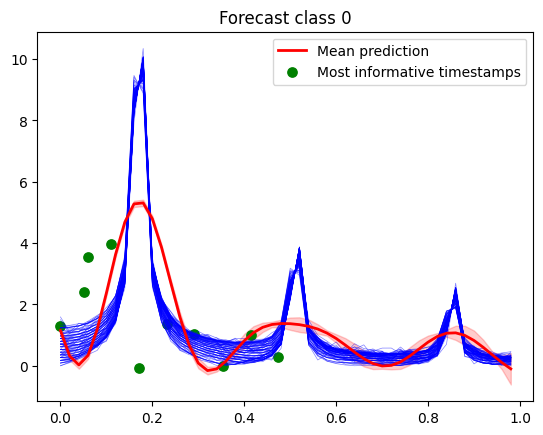

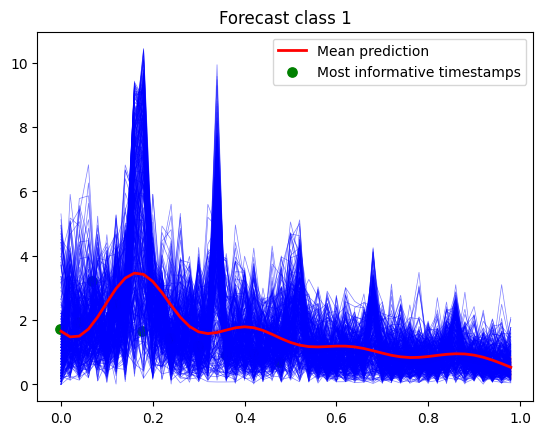

In [12]:
model = MultiPhaseAMModel(input_dim, num_inducing_points, num_latents, num_outputs, sigma_y=0.1).to(device)
model.load_state_dict(torch.load("saved_models/am_test.pth", map_location=device))


plot_forecast(X_train.to(device),Y_train.to(device),label=0)
plot_forecast(X_train.to(device),Y_train.to(device),label=1)
plt.show()


torch.Size([400, 512]) torch.Size([400, 512])
torch.Size([66, 50])
torch.Size([334, 50])


RuntimeError: Expected size for first two dimensions of batch2 tensor to be: [1, 1] but got: [1, 50].

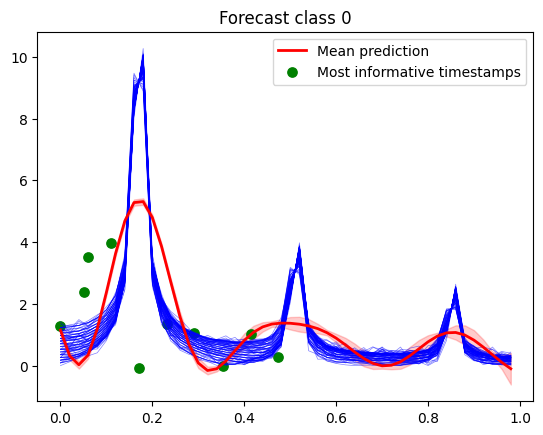

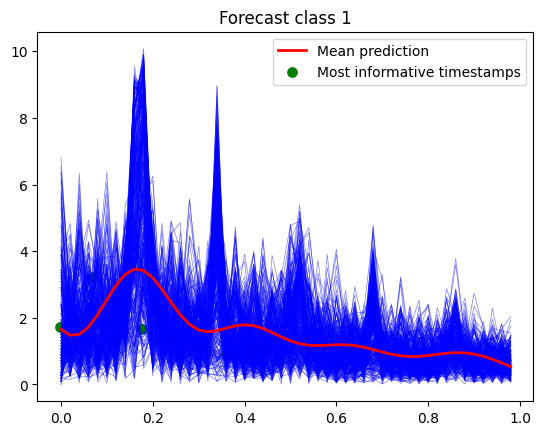

In [ ]:
loaders = iter(row_loader)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)

Y_test, labels_test = test_batch
Y_test.squeeze_()
X_test = torch.linspace(0, 1, Y_test.shape[1]).reshape(1, -1).repeat(Y_test.shape[0], 1)

plot_forecast(X_test.to(device),Y_test.to(device),label=0)
plot_forecast(X_test.to(device),Y_test.to(device),label=1)

model.update_from_obs(X_test.to(device), Y_test.to(device))

plot_forecast(X_test.to(device),Y_test.to(device),label=0)
plot_forecast(X_test.to(device),Y_test.to(device),label=1)
